### Create SMET Forcing Files from Met Station Data (filled with HRRR-AK (lapse-rate temp)): Point Simulation at the Tram
* Including lapse-rate correction with HRRR-AK temperature data 

created by Cassie Lumbrazo\
last updated: Sept 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

## Load Tram Data: Cleaned in `1_clean_met_tram_synoptic.ipynb'

In [3]:
# open observations
# file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
file = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  # should really replace this with the WY2026 data once I fix that...
ds_met = xr.open_dataset(file)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
ds_met = ds_met.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))

# convert temp to K for comparison with HRRR-AK data
ds_met['temp'] = ds_met['temp'] + 273.15

_________________________________________________________________

## Load the HRRR-AK Dataset

In [4]:
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_tram.nc"
ds_hrrr = xr.open_dataset(input_file)
ds_hrrr.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

# and clip to WY2020,2021,2022 
ds_hrrr = ds_hrrr.sel(time=slice("2022-10-01T05:00:00", "2025-09-30T05:00:00"))

ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

# remove that large precip_accum_1hr spike in the hrrr data and change it to 0 for now 
ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_accum_1hr'].where(ds_hrrr['precip_accum_1hr'] < 30, 0)

Air temperature, 

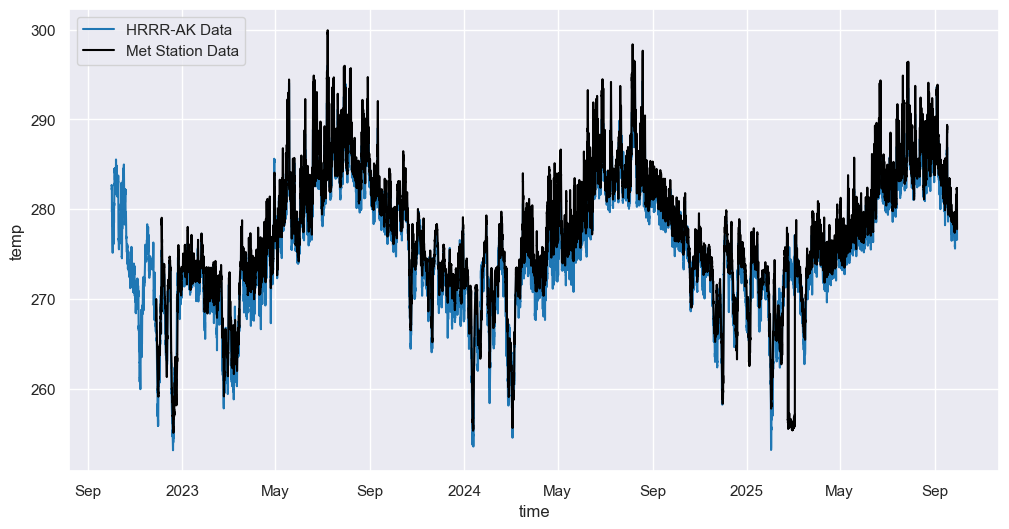

In [5]:
# compare temp
ds_hrrr.temp.plot(label='HRRR-AK Data', color='tab:blue')
ds_met.temp.plot(label='Met Station Data', color='black')
# for WY2025, there is a weird temperature drop so remove any temperatures in ds_met that are below 258
ds_met = ds_met.where(ds_met['temp'] >= 258, drop=True)
plt.legend()

### Removing the chunck of data around the model crash date,

In [6]:
# remove a chunck of ds_met data around the crash date : 23-10-12T00:00:00

# This one did not work 
# ds_met = ds_met.where(~((ds_met['time'] >= "2023-10-11T00:00:00") & (ds_met['time'] <= "2023-10-13T00:00:00")), drop=True)

# This one worked 
ds_met = ds_met.where(~((ds_met['time'] >= np.datetime64("2023-06-11T00:00:00")) & (ds_met['time'] <= np.datetime64("2023-11-01T00:00:00"))), drop=True)

# I could try a smaller date range or only RH for example in the future if I have more time

# Now, remove data which just looks bad because precip just is not accumulating properly 
# remove 2023-11-15 through 2023-12-22 
ds_met = ds_met.where(~((ds_met['time'] >= np.datetime64("2023-11-15T00:00:00")) & (ds_met['time'] <= np.datetime64("2023-12-22T00:00:00"))), drop=True)

# And, the worst section remove 15 April 2024 through 15 July 2024 
ds_met = ds_met.where(~((ds_met['time'] >= np.datetime64("2024-04-15T00:00:00")) & (ds_met['time'] <= np.datetime64("2024-07-15T00:00:00"))), drop=True)

HRRR to MeteIO Variable Mapping 

In [7]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [8]:
from pathlib import Path
from pyproj import Transformer

In [9]:
# lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
# lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [10]:
# relate the variables, df_met is for the met station data 
ds_met = ds_met.copy()

# ds is for the HRRRAK data
ds_hrrrak = ds_hrrr.copy()

New Code, 

In [11]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
import matplotlib.pyplot as plt

# ============================================================
# USER SETTINGS
# ============================================================

start_time = "2022-10-01T05:00"
end_time   = "2025-09-30T05:00"

TIMESTEP = "1h"

OUTFILE = Path(
    "/home/cassie/python/models/run_snowpack/sites/tram/input/"
    "/met_hrrrak_lapserate_WY2023-WY2025/met_hrrrak_lapserate_tram_WY2023-WY2025.smet"
)

STATION_ID   = "met_hrrrak_lapserate_tram_WY2023-WY2025"
STATION_NAME = "Met Station and HRRR-AK Lapse-rate Temperature TRAM Point Forcing"

LAT  = lat_tram
LON  = lon_tram
ELEV = elevation_tram

# HRRR-AK grid-cell elevation at TRAM
HRRR_ELEV = 637.39

# Lapse rate: positive value, K/m or °C/m
# LAPSE_RATE = 0.0065
LAPSE_RATE = 0.006 # going to use 6 degC/km

EPSG   = 32608
TZ     = 0
NODATA = -999

# ============================================================
# TEMPERATURE LAPSE-RATE CORRECTION
# ============================================================

elevation_difference = ELEV - HRRR_ELEV
temperature_correction = -LAPSE_RATE * elevation_difference

print("\nLapse-rate correction:")
print(f"Site elevation: {ELEV:.2f} m")
print(f"HRRR elevation: {HRRR_ELEV:.2f} m")
print(f"Elevation difference, site - HRRR: {elevation_difference:.2f} m")
print(f"Temperature correction applied to HRRR fill TA: {temperature_correction:+.2f} K")

# ============================================================
# SLICE TO COMMON TIME RANGE
# ============================================================

ds_met = ds_met.sel(time=slice(start_time, end_time))
ds_hrrrak = ds_hrrrak.sel(time=slice(start_time, end_time))

print("\nOriginal dataset ranges:")
print(f"MET:  {ds_met.time.min().values} -> {ds_met.time.max().values}")
print(f"HRRR: {ds_hrrrak.time.min().values} -> {ds_hrrrak.time.max().values}")

# ============================================================
# SORT TIME AXES
# ============================================================

ds_met = ds_met.sortby("time")
ds_hrrrak = ds_hrrrak.sortby("time")

# ============================================================
# CREATE CONTINUOUS HOURLY TIME AXES
# ============================================================

ds_met = ds_met.resample(time="1h").asfreq()
ds_hrrrak = ds_hrrrak.resample(time="1h").asfreq()

# ============================================================
# ALIGN MET DATA TO HRRR TIME AXIS
# ============================================================

ds_met = ds_met.reindex(time=ds_hrrrak.time)

# ============================================================
# PRECIPITATION CHECK
# ============================================================

if "precip_accum_1hr" not in ds_met:
    raise KeyError(
        "ds_met['precip_accum_1hr'] does not exist. "
        "Create it in the upstream MET precipitation-cleaning script first."
    )

ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(
    ds_met["precip_accum_1hr"] >= 0
)

ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(
    ds_met["precip_accum_1hr"] <= 40
)

# ============================================================
# UNIT CONVERSIONS
# ============================================================

# ---- Relative Humidity ----
# Convert both datasets to fraction [0-1] only if they are currently percent.
# If already fraction, this avoids dividing twice.

if float(ds_met["rh"].max(skipna=True)) > 1.5:
    ds_met["rh"] = ds_met["rh"] / 100.0

if float(ds_hrrrak["rh"].max(skipna=True)) > 1.5:
    ds_hrrrak["rh"] = ds_hrrrak["rh"] / 100.0

# ---- Temperature ----
# SNOWPACK forcing TA is kept in Kelvin.
# Apply lapse-rate correction ONLY to HRRR-AK temperature.
# MET temperature remains unchanged.

ds_hrrrak["temp_lapserate"] = ds_hrrrak["temp"] + temperature_correction


# ============================================================
# DIAGNOSTIC CHECKS
# ============================================================

print("\nCoverage statistics:")

print(
    "MET precip valid fraction:",
    float(ds_met["precip_accum_1hr"].notnull().mean())
)

print(
    "HRRR precip valid fraction:",
    float(ds_hrrrak["precip_accum_1hr"].notnull().mean())
)

print(
    "MET TA valid fraction:",
    float(ds_met["temp"].notnull().mean())
)

print(
    "HRRR TA fill valid fraction:",
    float(ds_hrrrak["temp_lapserate"].notnull().mean())
)

# ============================================================
# CREATE FINAL FILLED FORCING DATASET
# ============================================================

ds_filled = xr.Dataset(coords={"time": ds_hrrrak.time})

# MET first, lapse-rate corrected HRRR-AK fill
ds_filled["TA"] = ds_met["temp"].combine_first(ds_hrrrak["temp_lapserate"])

# DEBUG CODE --------------------------------------------------------------------------------------------
# ============================================================
# SNOWPACK INITIALIZATION STABILITY FIX
# ============================================================
# During an early-season precipitation event on 23-24 Oct 2022,
# the +0.65 K HRRR lapse-rate TA correction caused SNOWPACK to
# become numerically unstable and segfault.
#
# Use raw HRRR TA over this short initialization window only.
# Lapse-rate-corrected HRRR TA is used at all other times when
# MET temperature is unavailable.

stability_start = np.datetime64("2022-10-23T12:00")
stability_end   = np.datetime64("2022-10-24T12:00")

stability_mask = (
    (ds_filled.time >= stability_start)
    & (ds_filled.time <= stability_end)
)

ds_filled["TA"] = xr.where(
    stability_mask,
    ds_hrrrak["temp"],
    ds_filled["TA"]
)

# DEBUG CODE --------------------------------------------------------------------------------------------

# MET first, raw HRRR-AK fill
ds_filled["RH"] = ds_met["rh"].combine_first(ds_hrrrak["rh"])
ds_filled["PSUM"] = ds_met["precip_accum_1hr"].combine_first(
    ds_hrrrak["precip_accum_1hr"]
)

# Always raw HRRR-AK
ds_filled["ISWR"] = ds_hrrrak["swrad"]
ds_filled["ILWR"] = ds_hrrrak["lwrad"]
ds_filled["PS"]   = ds_hrrrak["pressure"]

u = ds_hrrrak["10u"]
v = ds_hrrrak["10v"]

ds_filled["VW"] = np.sqrt(u**2 + v**2)
ds_filled["DW"] = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0

# ============================================================
# DIAGNOSTIC OUTPUT
# ============================================================

met_ta_used = ds_met["temp"].notnull()
hrrr_ta_fill_used = ds_met["temp"].isnull() & ds_hrrrak["temp_lapserate"].notnull()

met_rh_used = ds_met["rh"].notnull()
hrrr_rh_fill_used = ds_met["rh"].isnull() & ds_hrrrak["rh"].notnull()

met_psum_used = ds_met["precip_accum_1hr"].notnull()
hrrr_psum_fill_used = (
    ds_met["precip_accum_1hr"].isnull()
    & ds_hrrrak["precip_accum_1hr"].notnull()
)

print("\nFraction of timesteps using MET data:")
print("TA:", float(met_ta_used.mean()))
print("RH:", float(met_rh_used.mean()))
print("PSUM:", float(met_psum_used.mean()))

print("\nFill source diagnostics:")
print("MET TA timesteps used:", int(met_ta_used.sum()))
print("HRRR lapse-rate TA fill timesteps:", int(hrrr_ta_fill_used.sum()))
print("Missing final TA timesteps:", int(ds_filled["TA"].isnull().sum()))

print("MET RH timesteps used:", int(met_rh_used.sum()))
print("HRRR raw RH fill timesteps:", int(hrrr_rh_fill_used.sum()))
print("Missing final RH timesteps:", int(ds_filled["RH"].isnull().sum()))

print("MET PSUM timesteps used:", int(met_psum_used.sum()))
print("HRRR raw PSUM fill timesteps:", int(hrrr_psum_fill_used.sum()))
print("Missing final PSUM timesteps:", int(ds_filled["PSUM"].isnull().sum()))

print("\nPSUM totals:")
print("MET PSUM total:", float(ds_met["precip_accum_1hr"].sum(skipna=True)))
print("HRRR PSUM total:", float(ds_hrrrak["precip_accum_1hr"].sum(skipna=True)))
print("Final mixed PSUM total:", float(ds_filled["PSUM"].sum(skipna=True)))

# DEBUG CODE --------------------------------------------------------------------------------------------

print(
    debug.loc[
        "2022-10-23T12:00":"2022-10-24T10:00",
        ["HRRR_TA_C", "LAPSE_TA_C", "RH", "PSUM"]
    ].to_string()
)

# DEBUG CODE --------------------------------------------------------------------------------------------


# ============================================================
# CONVERT TO DATAFRAME
# ============================================================

df_smet = ds_filled.to_dataframe()

# ============================================================
# FINAL TIME HANDLING
# ============================================================

df_smet = df_smet.asfreq(TIMESTEP)

# ============================================================
# REPLACE MISSING VALUES
# ============================================================

df_smet = df_smet.fillna(NODATA)

# ============================================================
# COORDINATE TRANSFORM
# ============================================================

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32608",
    always_xy=True
)

EASTING, NORTHING = transformer.transform(LON, LAT)

# ============================================================
# WRITE SMET FILE
# ============================================================

OUTFILE.parent.mkdir(parents=True, exist_ok=True)

with open(OUTFILE, "w") as f:

    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write(
        "source           = MET temperature, relative humidity, and precipitation "
        "filled with HRRR-AK; HRRR-AK temperature fill lapse-rate corrected to site elevation\n"
    )
    f.write(f"lapse_rate       = {LAPSE_RATE:.4f} K m-1\n")
    f.write(f"hrrr_elevation   = {HRRR_ELEV:.2f} m\n")
    f.write(f"site_elevation   = {ELEV:.2f} m\n")
    f.write(f"ta_correction    = {temperature_correction:.3f} K\n")

    f.write(
        "fields           = "
        "timestamp TA RH VW DW ISWR ILWR PSUM PS\n"
    )

    f.write("[DATA]\n")

    for t, row in df_smet.iterrows():

        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} "
            f"{row.RH:6.3f} "
            f"{row.VW:6.2f} "
            f"{row.DW:6.1f} "
            f"{row.ISWR:8.1f} "
            f"{row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} "
            f"{row.PS:8.1f}\n"
        )

print(f"\nSMET file written to:\n{OUTFILE}")

# ============================================================
# PRECIPITATION COMPARISON PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    ds_hrrrak["precip_accum_1hr"].to_series().cumsum(),
    label="HRRR-AK raw precip",
)

plt.plot(
    ds_met["precip_accum_1hr"].to_series().cumsum(),
    label="MET precip",
)

plt.plot(
    ds_filled["PSUM"].to_series().cumsum(),
    label="Mixed precip",
)

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")
plt.title("Cumulative Precipitation Comparison\nTRAM WY2023-WY2025")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# TEMPERATURE FILL DIAGNOSTIC PLOT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    (ds_hrrrak["temp"] - 273.15).to_series(),
    label="HRRR-AK raw TA",
    alpha=0.7,
)

plt.plot(
    (ds_hrrrak["temp_lapserate"] - 273.15).to_series(),
    label=f"HRRR-AK lapse-rate TA ({temperature_correction:+.2f} K)",
    alpha=0.7,
)

plt.plot(
    (ds_met["temp"] - 273.15).to_series(),
    label="MET TA",
    alpha=0.6,
)

plt.ylabel("Air temperature (°C)")
plt.xlabel("Time")
plt.title("Temperature Forcing Comparison\nTRAM WY2023-WY2025")
plt.axhline(0, color="k", linestyle="--", linewidth=1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


Lapse-rate correction:
Site elevation: 529.00 m
HRRR elevation: 637.39 m
Elevation difference, site - HRRR: -108.39 m
Temperature correction applied to HRRR fill TA: +0.65 K

Original dataset ranges:
MET:  2022-11-27T16:00:00.000000000 -> 2025-09-30T05:00:00.000000000
HRRR: 2022-10-01T05:00:00.000000000 -> 2025-09-30T05:00:00.000000000



Coverage statistics:
MET precip valid fraction: 0.6831551310832921
HRRR precip valid fraction: 0.9999619496975001
MET TA valid fraction: 0.6831551310832921
HRRR TA fill valid fraction: 0.9999619496975001

Fraction of timesteps using MET data:
TA: 0.6831551310832921
RH: 0.6831551310832921
PSUM: 0.6831551310832921

Fill source diagnostics:
MET TA timesteps used: 17954
HRRR lapse-rate TA fill timesteps: 8326
Missing final TA timesteps: 1
MET RH timesteps used: 17954
HRRR raw RH fill timesteps: 8326
Missing final RH timesteps: 1
MET PSUM timesteps used: 17954
HRRR raw PSUM fill timesteps: 8326
Missing final PSUM timesteps: 1

PSUM totals:
MET PSUM total: 6260.083999999999
HRRR PSUM total: 13216.644
Final mixed PSUM total: 10825.676


NameError: name 'debug' is not defined

## Create .SNO File 

In [ ]:
# ============================================================
# CREATE EMPTY .SNO FILE
# ============================================================

# ============================================================
# OUTPUT FILE
# ============================================================

OUTFILE_SNO = OUTFILE.with_suffix(".sno")
OUTFILE_SNO.parent.mkdir(parents=True, exist_ok=True)

# ============================================================
# PROFILE DATE
# ============================================================

# Use the first timestamp in the final SMET dataframe
forcing_start_time = df_smet.index.min()

# SNOWPACK commonly initializes one timestep after forcing start
profile_date = pd.to_datetime(forcing_start_time) + pd.to_timedelta(TIMESTEP)
profile_date_str = profile_date.strftime("%Y-%m-%dT%H:%M")

# ============================================================
# OPTIONAL SITE PARAMETERS
# ============================================================

SLOPE_ANGLE = 38.0
SLOPE_AZI   = 0.0

SOIL_ALBEDO = 0.09
BARE_SOIL_Z0 = 0.200

CANOPY_HEIGHT = 0.00
CANOPY_LAI = 0.00
CANOPY_DIRECT_THROUGHFALL = 1.00

WIND_SCALING_FACTOR = 1.00

# ============================================================
# WRITE SNO FILE
# ============================================================

with open(OUTFILE_SNO, "w") as f:

    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")

    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")

    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")

    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")

    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")

    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")

    f.write(
        "source           = MET temperature, relative humidity, and precipitation "
        "filled with HRRR-AK; HRRR-AK temperature fill lapse-rate corrected to site elevation\n"
    )
    f.write(f"lapse_rate       = {LAPSE_RATE:.4f} K m-1\n")
    f.write(f"hrrr_elevation   = {HRRR_ELEV:.2f} m\n")
    f.write(f"site_elevation   = {ELEV:.2f} m\n")
    f.write(f"ta_correction    = {temperature_correction:.3f} K\n")

    f.write(f"ProfileDate      = {profile_date_str}\n")
    f.write("HS_Last          = 0.0000\n")

    f.write(f"SlopeAngle       = {SLOPE_ANGLE:.1f}\n")
    f.write(f"SlopeAzi         = {SLOPE_AZI:.1f}\n")

    f.write("nSoilLayerData   = 0\n")
    f.write("nSnowLayerData   = 0\n")

    f.write(f"SoilAlbedo       = {SOIL_ALBEDO:.2f}\n")
    f.write(f"BareSoil_z0      = {BARE_SOIL_Z0:.3f}\n")

    f.write(f"CanopyHeight     = {CANOPY_HEIGHT:.2f}\n")
    f.write(f"CanopyLeafAreaIndex = {CANOPY_LAI:.2f}\n")
    f.write(f"CanopyDirectThroughfall = {CANOPY_DIRECT_THROUGHFALL:.2f}\n")
    f.write(f"WindScalingFactor = {WIND_SCALING_FACTOR:.2f}\n")

    f.write("ErosionLevel     = 0\n")
    f.write("TimeCountDeltaHS = 0.000000\n")

    f.write(
        "fields           = "
        "timestamp Layer_Thick T Vol_Frac_I "
        "Vol_Frac_W Vol_Frac_V Vol_Frac_S "
        "Rho_S Conduc_S HeatCapac_S "
        "rg rb dd sp mk mass_hoar ne CDot metamo\n"
    )

    f.write("[DATA]\n")

print(f"\nSNO file written to:\n{OUTFILE_SNO}")


SNO file written to:
/home/cassie/python/models/run_snowpack/sites/tram/input/met_hrrrak_lapserate_WY2023-WY2025/met_hrrrak_lapserate_tram_WY2023-WY2025.sno


In [ ]:
# ============================================================
# TEMPERATURE FILL / FREEZING THRESHOLD DIAGNOSTICS
# ============================================================

FREEZING_K = 273.15

# Timesteps where MET temperature is missing,
# so HRRR-AK temperature is actually used as the TA fill
hrrr_ta_fill_used = (
    ds_met["temp"].isnull()
    & ds_hrrrak["temp"].notnull()
)

# Raw HRRR and lapse-rate corrected HRRR temperatures during fill timesteps
ta_raw_fill = ds_hrrrak["temp"].where(hrrr_ta_fill_used)
ta_lapse_fill = ds_hrrrak["temp_lapserate"].where(hrrr_ta_fill_used)

# Phase-relevant threshold changes
raw_above_lapse_below = (
    hrrr_ta_fill_used
    & (ds_hrrrak["temp"] > FREEZING_K)
    & (ds_hrrrak["temp_lapserate"] <= FREEZING_K)
)

raw_below_lapse_above = (
    hrrr_ta_fill_used
    & (ds_hrrrak["temp"] <= FREEZING_K)
    & (ds_hrrrak["temp_lapserate"] > FREEZING_K)
)

n_fill = int(hrrr_ta_fill_used.sum())
n_raw_above_lapse_below = int(raw_above_lapse_below.sum())
n_raw_below_lapse_above = int(raw_below_lapse_above.sum())

print("\n===== TA fill freezing-threshold diagnostic =====")
print(f"HRRR TA fill timesteps: {n_fill}")
print(
    "Raw HRRR > 0°C, lapse-rate HRRR <= 0°C:",
    n_raw_above_lapse_below
)
print(
    "Raw HRRR <= 0°C, lapse-rate HRRR > 0°C:",
    n_raw_below_lapse_above
)

if n_fill > 0:
    print(
        "Fraction of HRRR TA fill timesteps crossing freezing:",
        f"{100 * (n_raw_above_lapse_below + n_raw_below_lapse_above) / n_fill:.2f}%"
    )

# Optional: same diagnostic only during precipitation
precip_during_fill = (
    hrrr_ta_fill_used
    & ds_filled["PSUM"].notnull()
    & (ds_filled["PSUM"] > 0.1)
)

raw_above_lapse_below_precip = raw_above_lapse_below & precip_during_fill
raw_below_lapse_above_precip = raw_below_lapse_above & precip_during_fill

n_fill_precip = int(precip_during_fill.sum())
n_raw_above_lapse_below_precip = int(raw_above_lapse_below_precip.sum())
n_raw_below_lapse_above_precip = int(raw_below_lapse_above_precip.sum())

precip_raw_above_lapse_below = float(
    ds_filled["PSUM"].where(raw_above_lapse_below_precip).sum(skipna=True)
)

precip_raw_below_lapse_above = float(
    ds_filled["PSUM"].where(raw_below_lapse_above_precip).sum(skipna=True)
)

print("\n===== TA fill freezing-threshold diagnostic during precip =====")
print(f"HRRR TA fill timesteps with precip > 0.1 mm/hr: {n_fill_precip}")
print(
    "Raw HRRR > 0°C, lapse-rate HRRR <= 0°C:",
    n_raw_above_lapse_below_precip,
    f"({precip_raw_above_lapse_below:.1f} mm precip)"
)
print(
    "Raw HRRR <= 0°C, lapse-rate HRRR > 0°C:",
    n_raw_below_lapse_above_precip,
    f"({precip_raw_below_lapse_above:.1f} mm precip)"
)


===== TA fill freezing-threshold diagnostic =====
HRRR TA fill timesteps: 8326
Raw HRRR > 0°C, lapse-rate HRRR <= 0°C: 0
Raw HRRR <= 0°C, lapse-rate HRRR > 0°C: 283
Fraction of HRRR TA fill timesteps crossing freezing: 3.40%

===== TA fill freezing-threshold diagnostic during precip =====
HRRR TA fill timesteps with precip > 0.1 mm/hr: 2356
Raw HRRR > 0°C, lapse-rate HRRR <= 0°C: 0 (0.0 mm precip)
Raw HRRR <= 0°C, lapse-rate HRRR > 0°C: 119 (196.4 mm precip)


## Forcing Figure Plot

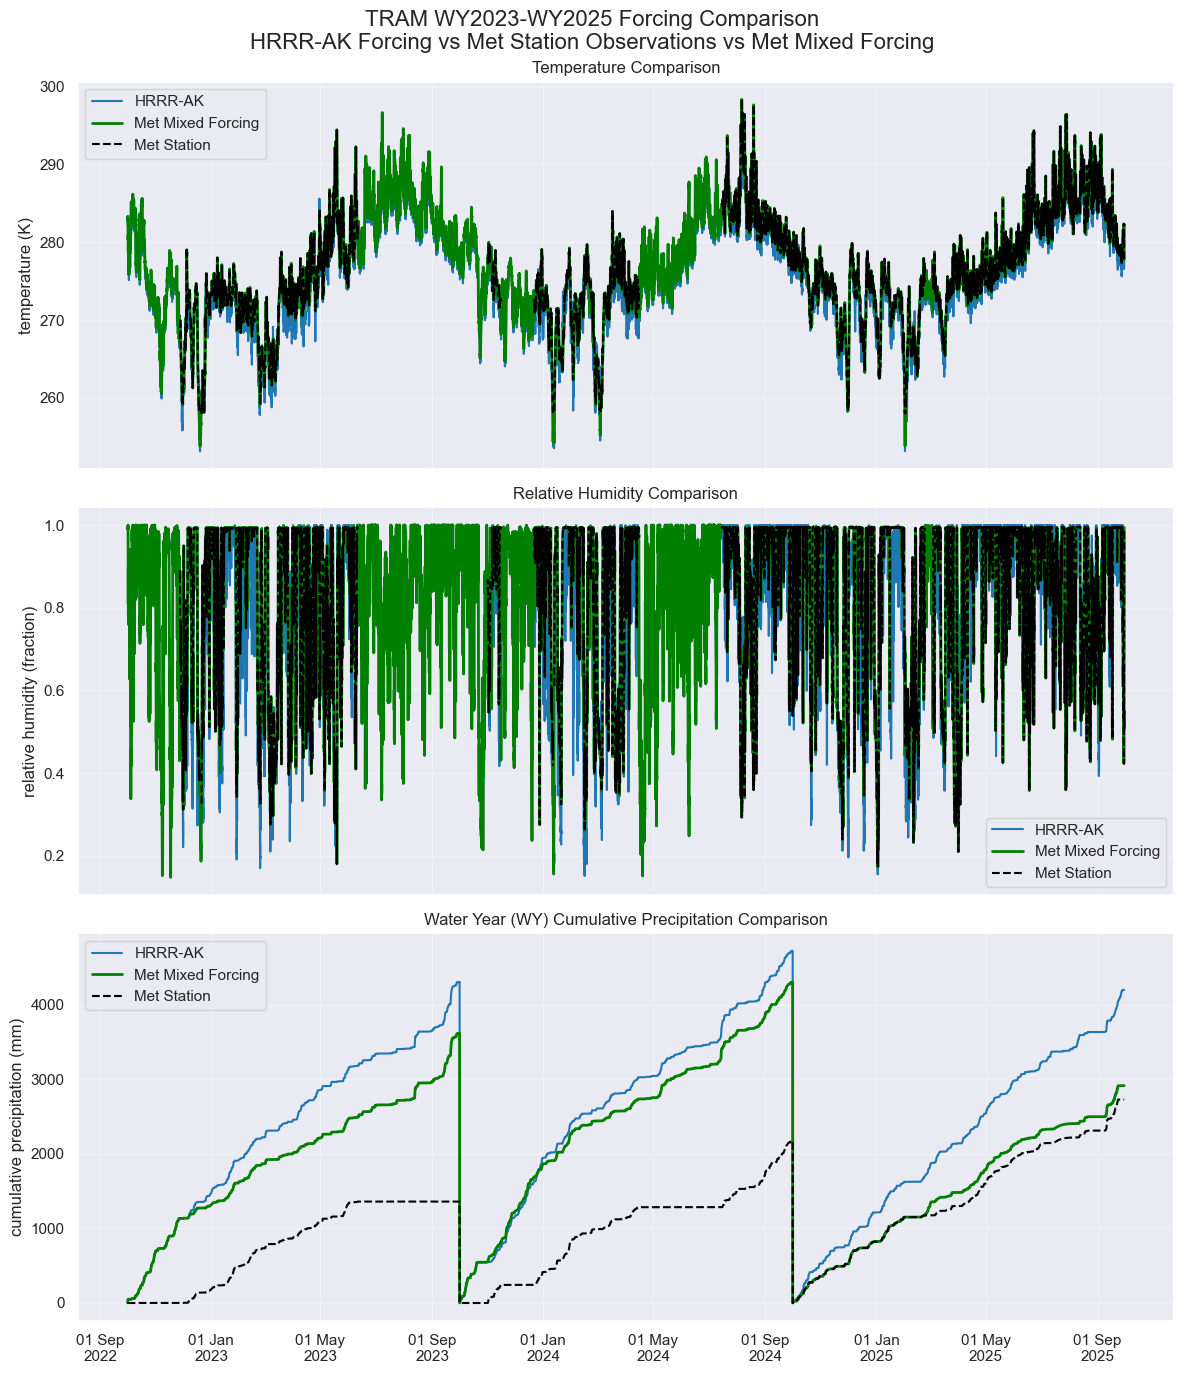

In [ ]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# ============================================================
# MULTI-VARIABLE COMPARISON PLOT
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 14),
    sharex=True
)

# ============================================================
# TEMPERATURE
# ============================================================

ax = axes[0]

# All datasets already aligned and in Kelvin

ax.plot(
    ds_hrrrak["temp"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_filled["TA"].to_series(),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2
)

ax.plot(
    ds_met["temp"].to_series(),
    label="Met Station",
    color="black",
    linestyle="--",
    
)

ax.set_ylabel("temperature (K)")
ax.set_title("Temperature Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# RELATIVE HUMIDITY
# ============================================================

ax = axes[1]

# RH already converted to fraction [0-1]

ax.plot(
    ds_hrrrak["rh"].to_series(),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    ds_filled["RH"].to_series(),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2
)

ax.plot(
    ds_met["rh"].to_series(),
    label="Met Station",
    color="black",
    linestyle="--",
)

ax.set_ylabel("relative humidity (fraction)")
ax.set_title("Relative Humidity Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# PRECIPITATION
# ============================================================

ax = axes[2]

def wateryear_cumsum(da, wy_start_month=10):
    """
    Cumulative sum that resets at the start of each water year.
    Water year starts on Oct 1 by default.
    """
    s = da.fillna(0).to_series()

    # Water year label: Oct-Dec belong to next calendar year
    wy = s.index.year + (s.index.month >= wy_start_month)

    return s.groupby(wy).cumsum()


ax.plot(
    wateryear_cumsum(ds_hrrrak["precip_accum_1hr"]),
    label="HRRR-AK",
    color="tab:blue"
)

ax.plot(
    wateryear_cumsum(ds_filled["PSUM"]),
    label="Met Mixed Forcing",
    color="green",
    linewidth=2,
)

ax.plot(
    wateryear_cumsum(ds_met["precip_accum_1hr"]),
    label="Met Station",
    color="black",
    linestyle="--",
)

ax.set_ylabel("cumulative precipitation (mm)")
ax.set_title("Water Year (WY) Cumulative Precipitation Comparison")

ax.grid(alpha=0.3)
ax.legend()

# ============================================================
# COMMON X-AXIS
# ============================================================

def custom_date_formatter(x, pos):
    dt = mdates.num2date(x)
    return dt.strftime("%d %b\n%Y")

axes[-1].xaxis.set_major_formatter(
    FuncFormatter(custom_date_formatter)
)

axes[-1].set_xlabel("")

plt.suptitle(
    "TRAM WY2023-WY2025 Forcing Comparison\n"
    "HRRR-AK Forcing vs Met Station Observations vs Met Mixed Forcing",
    fontsize=16
)

plt.tight_layout()

plt.show()

Zoom into WY2024...

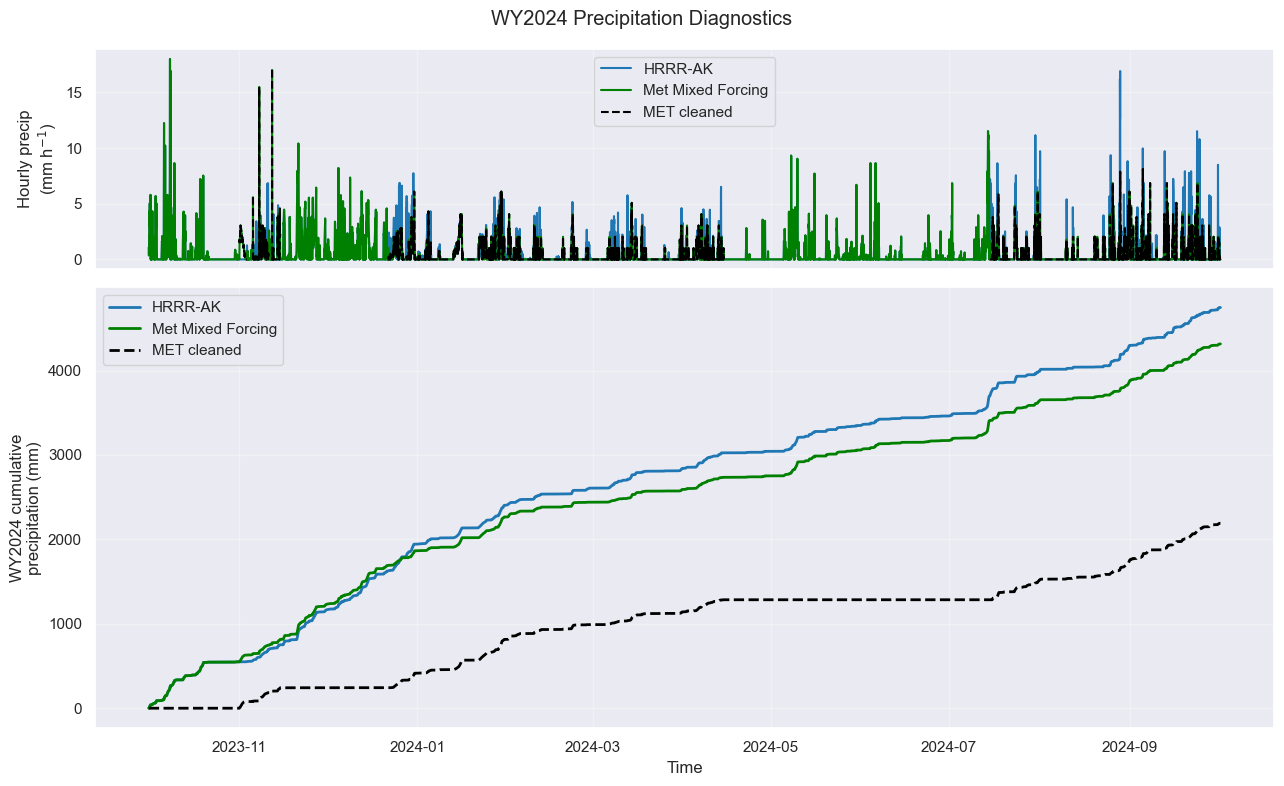

In [ ]:
# ============================================================
# PRECIPITATION DIAGNOSTIC PLOT — WY2024
# ============================================================

import matplotlib.pyplot as plt
import xarray as xr

wy_start = "2023-10-01"
wy_end   = "2024-10-01"

# Slice WY2024
met_wy = ds_met.sel(time=slice(wy_start, wy_end))
hrrr_wy = ds_hrrrak.sel(time=slice(wy_start, wy_end))
filled_wy = ds_filled.sel(time=slice(wy_start, wy_end))

# Water-year cumulative precipitation
met_cum = met_wy["precip_accum_1hr"].fillna(0).cumsum(dim="time")
hrrr_cum = hrrr_wy["precip_accum_1hr"].fillna(0).cumsum(dim="time")
filled_cum = filled_wy["PSUM"].fillna(0).cumsum(dim="time")

# Plot
fig, axes = plt.subplots(
    2, 1,
    figsize=(13, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 2]}
)

# ------------------------------------------------------------
# Hourly precipitation
# ------------------------------------------------------------

axes[0].plot(
    hrrr_wy.time,
    hrrr_wy["precip_accum_1hr"],
    label="HRRR-AK",
    color='tab:blue',
)

axes[0].plot(
    filled_wy.time,
    filled_wy["PSUM"],
    label="Met Mixed Forcing",
    color='green',
)

axes[0].plot(
    met_wy.time,
    met_wy["precip_accum_1hr"],
    label="MET cleaned",
    color='black',
    linestyle="--",
)

axes[0].set_ylabel("Hourly precip\n(mm h$^{-1}$)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# Cumulative precipitation
# ------------------------------------------------------------

axes[1].plot(
    hrrr_wy.time,
    hrrr_cum,
    label="HRRR-AK",
    linewidth=2,
    color="tab:blue",
)

axes[1].plot(
    filled_wy.time,
    filled_cum,
    label="Met Mixed Forcing",
    linewidth=2,
    color="green",
)

axes[1].plot(
    met_wy.time,
    met_cum,
    label="MET cleaned",
    linewidth=2,
    color="black",
    linestyle='--'
)

axes[1].set_ylabel("WY2024 cumulative\nprecipitation (mm)")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("WY2024 Precipitation Diagnostics", y=0.98)

plt.tight_layout()
plt.show()

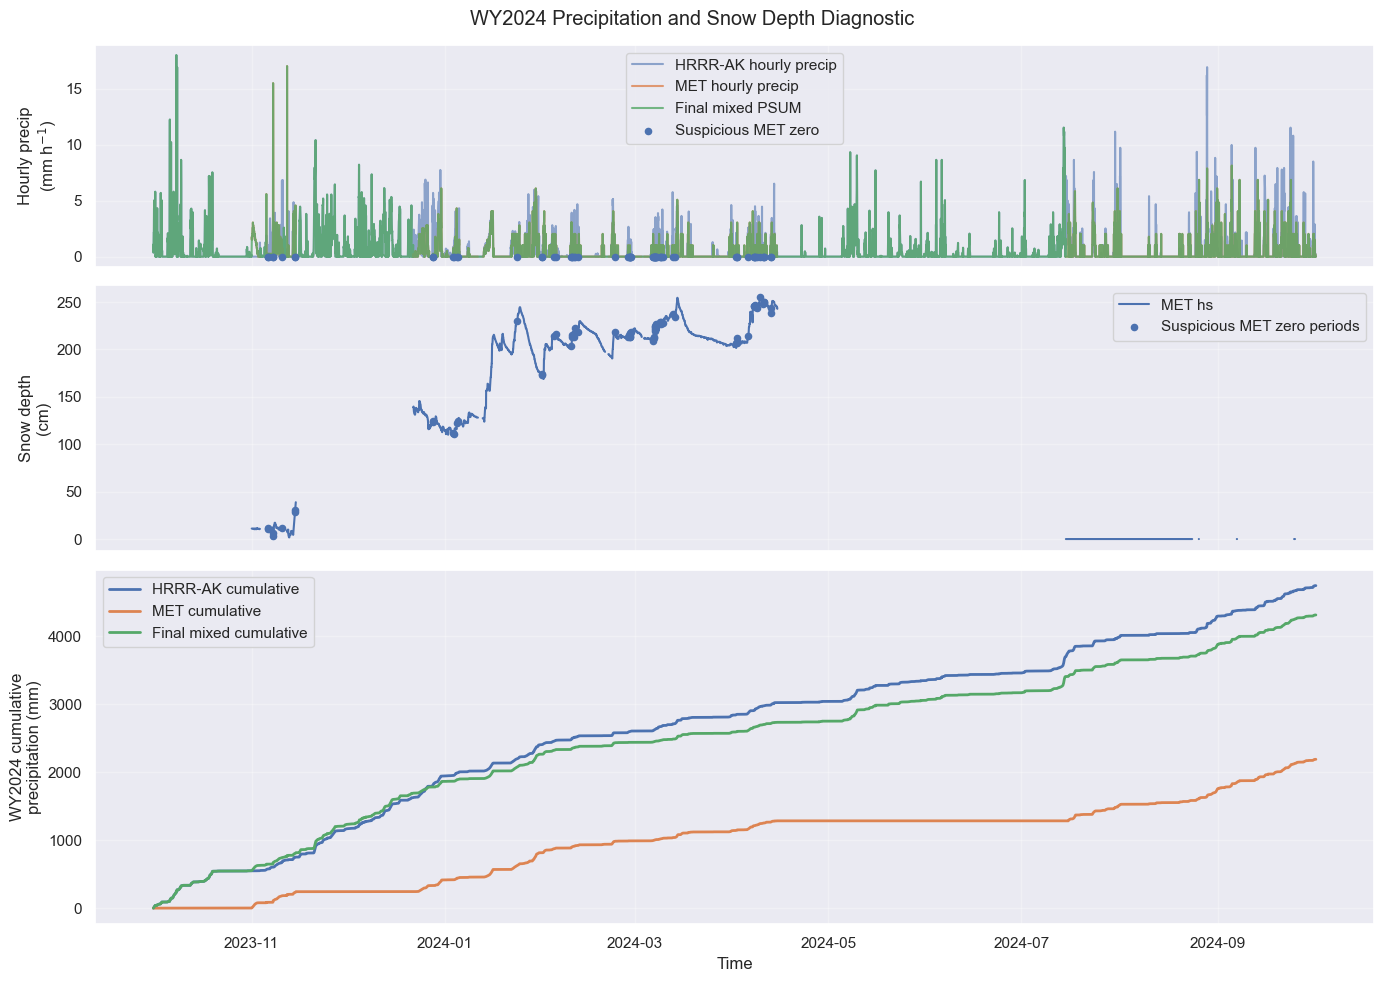


WY2024 suspicious MET zero diagnostics
MET zero + HRRR wet timesteps: 603
MET zero + HRRR wet + snow depth increasing: 64

WY2024 totals
MET precip total: 2190.2419999999997
HRRR precip total: 4746.888
Mixed precip total: 4315.106


In [ ]:
# ============================================================
# WY2024 PRECIP + SNOW DEPTH DIAGNOSTIC
# ============================================================

import matplotlib.pyplot as plt

wy_start = "2023-10-01"
wy_end   = "2024-10-01"

met = ds_met.sel(time=slice(wy_start, wy_end))
hrrr = ds_hrrrak.sel(time=slice(wy_start, wy_end))
filled = ds_filled.sel(time=slice(wy_start, wy_end))

# Choose snow-depth variable
hs_var = "hs_clean" if "hs_clean" in met else "hs"

# Cumulative precip
met_cum = met["precip_accum_1hr"].fillna(0).cumsum(dim="time")
hrrr_cum = hrrr["precip_accum_1hr"].fillna(0).cumsum(dim="time")
filled_cum = filled["PSUM"].fillna(0).cumsum(dim="time")

# Suspicious periods:
# MET reports zero, HRRR reports precipitation, and snow depth exists/increases.
met_zero_hrrr_wet = (
    met["precip_accum_1hr"].notnull()
    & (met["precip_accum_1hr"] == 0)
    & hrrr["precip_accum_1hr"].notnull()
    & (hrrr["precip_accum_1hr"] > 0.1)
)

# Snow-depth change
dhs = met[hs_var].diff("time")
dhs = xr.concat(
    [xr.full_like(met[hs_var].isel(time=0), np.nan), dhs],
    dim="time"
)
dhs = dhs.assign_coords(time=met.time)

snow_depth_increasing = dhs > 0.5

suspicious_zero = met_zero_hrrr_wet & snow_depth_increasing

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.2, 1.6]}
)

# ------------------------------------------------------------
# Hourly precip
# ------------------------------------------------------------

axes[0].plot(
    hrrr.time,
    hrrr["precip_accum_1hr"],
    label="HRRR-AK hourly precip",
    alpha=0.6,
)

axes[0].plot(
    met.time,
    met["precip_accum_1hr"],
    label="MET hourly precip",
    alpha=0.8,
)

axes[0].plot(
    filled.time,
    filled["PSUM"],
    label="Final mixed PSUM",
    alpha=0.8,
)

axes[0].scatter(
    met.time.where(suspicious_zero, drop=True),
    met["precip_accum_1hr"].where(suspicious_zero, drop=True),
    s=20,
    label="Suspicious MET zero",
    zorder=5,
)

axes[0].set_ylabel("Hourly precip\n(mm h$^{-1}$)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# Snow depth
# ------------------------------------------------------------

axes[1].plot(
    met.time,
    met[hs_var],
    label=f"MET {hs_var}",
    linewidth=1.5,
)

axes[1].scatter(
    met.time.where(suspicious_zero, drop=True),
    met[hs_var].where(suspicious_zero, drop=True),
    s=20,
    label="Suspicious MET zero periods",
    zorder=5,
)

axes[1].set_ylabel("Snow depth\n(cm)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ------------------------------------------------------------
# Cumulative precip
# ------------------------------------------------------------

axes[2].plot(
    hrrr.time,
    hrrr_cum,
    label="HRRR-AK cumulative",
    linewidth=2,
)

axes[2].plot(
    met.time,
    met_cum,
    label="MET cumulative",
    linewidth=2,
)

axes[2].plot(
    filled.time,
    filled_cum,
    label="Final mixed cumulative",
    linewidth=2,
)

axes[2].set_ylabel("WY2024 cumulative\nprecipitation (mm)")
axes[2].set_xlabel("Time")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle(
    "WY2024 Precipitation and Snow Depth Diagnostic",
    y=0.98
)

# zoom into may 2024 
# axes[2].set_xlim("2024-05-01", "2024-06-30")

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY DIAGNOSTICS
# ============================================================

print("\nWY2024 suspicious MET zero diagnostics")
print("MET zero + HRRR wet timesteps:", int(met_zero_hrrr_wet.sum()))
print("MET zero + HRRR wet + snow depth increasing:", int(suspicious_zero.sum()))

print("\nWY2024 totals")
print("MET precip total:", float(met["precip_accum_1hr"].sum(skipna=True)))
print("HRRR precip total:", float(hrrr["precip_accum_1hr"].sum(skipna=True)))
print("Mixed precip total:", float(filled["PSUM"].sum(skipna=True)))